In [2]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

In [4]:
ROOT = "./"

training_set = pd.read_csv(ROOT + "Training and Testing Sets/" + "UNSW_NB15_training-set.csv")
testing_set = pd.read_csv(ROOT + "Training and Testing Sets/" + "UNSW_NB15_testing-set.csv")

print(training_set.head())
print(testing_set.head())

print(f"Value counts labels : {testing_set['label'].value_counts()}")
print(f"Value counts labels : {training_set['label'].value_counts()}")

# print number of normal for feature attack_cat
print(f"Value counts attack_cat : {testing_set['attack_cat'].value_counts()}")
print(f"Value counts attack_cat : {training_set['attack_cat'].value_counts()}")

# Drop the 'id' column if it exists
training_set = training_set.drop(columns=['id'], errors='ignore')
testing_set = testing_set.drop(columns=['id'], errors='ignore')

# Print all the columns in the dataset
print(f"Columns in training set: {training_set.columns.tolist()}")
print(f"Columns in testing set: {testing_set.columns.tolist()}")

print(training_set.shape)
print(testing_set.shape)

   id       dur proto service state  spkts  dpkts  sbytes  dbytes       rate  \
0   1  0.121478   tcp       -   FIN      6      4     258     172  74.087490   
1   2  0.649902   tcp       -   FIN     14     38     734   42014  78.473372   
2   3  1.623129   tcp       -   FIN      8     16     364   13186  14.170161   
3   4  1.681642   tcp     ftp   FIN     12     12     628     770  13.677108   
4   5  0.449454   tcp       -   FIN     10      6     534     268  33.373826   

   ...  ct_dst_sport_ltm  ct_dst_src_ltm  is_ftp_login  ct_ftp_cmd  \
0  ...                 1               1             0           0   
1  ...                 1               2             0           0   
2  ...                 1               3             0           0   
3  ...                 1               3             1           1   
4  ...                 1              40             0           0   

   ct_flw_http_mthd  ct_src_ltm  ct_srv_dst  is_sm_ips_ports  attack_cat  \
0                 0   

In [5]:
from sklearn.preprocessing import StandardScaler

# Preprocessing the data

training_set_processed = training_set.copy()
testing_set_processed = testing_set.copy()

training_missing_values = training_set_processed.isnull().sum().sum()
testing_missing_values = testing_set_processed.isnull().sum().sum()
print(f"Number of missing values in training set: {training_missing_values}")
print(f"Number of missing values in testing set: {testing_missing_values}")

training_set_processed = training_set_processed.dropna()
testing_set_processed = testing_set_processed.dropna()
print(f"Number of missing values after dropping: {training_set_processed.isnull().sum().sum()}")
print(f"Number of missing values after dropping: {testing_set_processed.isnull().sum().sum()}")

# Normalize the data

# Standardize features
scaler = StandardScaler()

# Standardize training dataset
feature_cols = training_set_processed.columns.drop(["attack_cat", "label"])
numerical_cols = training_set_processed[feature_cols].select_dtypes(include=["number"]).columns

# Show statistics before scaling
print(f"Original features shape: {training_set_processed[numerical_cols].shape}")
print(f"Before scaling (first feature):")
print(f"\tMean: {training_set_processed[numerical_cols[0]].mean():.4f}")
print(f"\tStd:  {training_set_processed[numerical_cols[0]].std():.4f}")
print(f"\tMin:  {training_set_processed[numerical_cols[0]].min():.4f}")
print(f"\tMax:  {training_set_processed[numerical_cols[0]].max():.4f}")

training_set_processed[numerical_cols] = scaler.fit_transform(training_set_processed[numerical_cols])

# Show statistics after scaling
print(f"\nScaled features shape: {training_set_processed[numerical_cols].shape}")
print(f"After scaling (first feature):")
print(f"\tMean: {training_set_processed[numerical_cols].iloc[:, 0].mean():.4f}")
print(f"\tStd:  {training_set_processed[numerical_cols].iloc[:, 0].std():.4f}")
print(f"\tMin:  {training_set_processed[numerical_cols].iloc[:, 0].min():.4f}")
print(f"\tMax:  {training_set_processed[numerical_cols].iloc[:, 0].max():.4f}")


# Standardize Wednesday dataset
feature_cols = testing_set_processed.columns.drop(["attack_cat", "label"])
numerical_cols = testing_set_processed[feature_cols].select_dtypes(include=["number"]).columns
# Show statistics before scaling
print(f"Original features shape: {testing_set_processed[numerical_cols].shape}")
print(f"Before scaling (first feature):")
print(f"\tMean: {testing_set_processed[numerical_cols[0]].mean():.4f}")
print(f"\tStd:  {testing_set_processed[numerical_cols[0]].std():.4f}")
print(f"\tMin:  {testing_set_processed[numerical_cols[0]].min():.4f}")
print(f"\tMax:  {testing_set_processed[numerical_cols[0]].max():.4f}")

testing_set_processed[numerical_cols] = scaler.fit_transform(testing_set_processed[numerical_cols])

# Show statistics after scaling
print(f"\nScaled features shape: {testing_set_processed[numerical_cols].shape}")
print(f"After scaling (first feature):")
print(f"\tMean: {testing_set_processed[numerical_cols].iloc[:, 0].mean():.4f}")
print(f"\tStd:  {testing_set_processed[numerical_cols].iloc[:, 0].std():.4f}")
print(f"\tMin:  {testing_set_processed[numerical_cols].iloc[:, 0].min():.4f}")
print(f"\tMax:  {testing_set_processed[numerical_cols].iloc[:, 0].max():.4f}")

Number of missing values in training set: 0
Number of missing values in testing set: 0
Number of missing values after dropping: 0
Number of missing values after dropping: 0
Original features shape: (175341, 39)
Before scaling (first feature):
	Mean: 1.3594
	Std:  6.4802
	Min:  0.0000
	Max:  60.0000

Scaled features shape: (175341, 39)
After scaling (first feature):
	Mean: -0.0000
	Std:  1.0000
	Min:  -0.2098
	Max:  9.0492
Original features shape: (82332, 39)
Before scaling (first feature):
	Mean: 1.0068
	Std:  4.7104
	Min:  0.0000
	Max:  60.0000

Scaled features shape: (82332, 39)
After scaling (first feature):
	Mean: -0.0000
	Std:  1.0000
	Min:  -0.2137
	Max:  12.5240


# 1. Comparative Security Modeling

## 1.1 Binary Intrusion Detection

In [6]:
X_train_bin = training_set_processed.drop(columns=["attack_cat", "label"])
y_train_bin = training_set_processed["label"]

X_test_bin = testing_set_processed.drop(columns=["attack_cat", "label"])
y_test_bin = testing_set_processed["label"]

In [7]:
print(f"Unique values in y_train_bin: {y_train_bin.unique()}")
print(f"Value counts in y_train_bin: {y_train_bin.value_counts()}")
print(f"Value counts in y_test_bin: {y_test_bin.value_counts()}")

# One hot encoding for all categorical features
X_train_bin = pd.get_dummies(X_train_bin)
X_test_bin = pd.get_dummies(X_test_bin)

print(X_train_bin.head())

# Aligner le set de validation sur le train
# On ajoute les colonnes manquantes (remplies de 0) et on supprime les colonnes en trop
X_test_bin = X_test_bin.reindex(columns=X_train_bin.columns, fill_value=False)

print(X_train_bin.head())
print(X_test_bin.head())

# Check values in label encoded
print(f"Unique values in y_train_bin: {y_train_bin.unique()}")
print(f"Unique values in y_test_bin: {y_test_bin.unique()}")
# check which value corresponds to attack and which to normal
print(f"Value counts in y_train_bin: {y_train_bin.value_counts()}")
print(f"Value counts in y_test_bin: {y_test_bin.value_counts()}")


Unique values in y_train_bin: [0 1]
Value counts in y_train_bin: label
1    119341
0     56000
Name: count, dtype: int64
Value counts in y_test_bin: label
1    45332
0    37000
Name: count, dtype: int64
        dur     spkts     dpkts    sbytes    dbytes      rate      sttl  \
0 -0.191029 -0.104456 -0.135769 -0.049134 -0.102726 -0.576371  0.703839   
1 -0.109485 -0.046014  0.172599 -0.046410  0.188544 -0.576345 -1.141901   
2  0.040699 -0.089845 -0.026933 -0.048527 -0.012133 -0.576734 -1.141901   
3  0.049729 -0.060624 -0.063212 -0.047016 -0.098563 -0.576737 -1.141901   
4 -0.140417 -0.075235 -0.117630 -0.047554 -0.102057 -0.576617  0.723268   

       dttl     sload     dload  ...  service_ssl  state_CON  state_ECO  \
0  1.578100 -0.389897 -0.273700  ...        False      False      False   
1  1.560002 -0.389928 -0.069233  ...        False      False      False   
2  1.560002 -0.389964 -0.252044  ...        False      False      False   
3  1.560002 -0.389958 -0.275821  ...        Fa

### Tuning XGBClassifier

In [8]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from xgboost import XGBClassifier
import time

In [ ]:
params = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.001, 0.005, 0.01, 0.05],
    'max_depth': [1, 2, 3, 5]
}

from scipy.stats import uniform, randint

p_grid = {
        "n_estimators": randint(100, 1000),
        "colsample_bytree": uniform(0.7, 0.3),
        "gamma": uniform(0, 0.5),
        "learning_rate": uniform(0.03, 0.3),
        "max_depth": randint(2, 8),        
        "subsample": uniform(0.6, 0.4)
}

start_time = time.time()

# bin_gs = GridSearchCV(XGBClassifier(n_jobs=-1, 
#                                     objective='binary:logistic', 
#                                     eval_metric='logloss'), 
#                         p_grid, 
#                         n_jobs=-1, 
#                         cv=3, 
#                         scoring='f1', 
#                         verbose=3)

bin_gs = RandomizedSearchCV(XGBClassifier(n_jobs=-1, 
                                    objective='binary:logistic', 
                                    eval_metric='logloss'), 
                        p_grid, 
                        n_jobs=-1, 
                        cv=3, 
                        scoring='f1', 
                        verbose=3,
                        n_iter=10)


bin_gs.fit(X_train_bin, y_train_bin)

end_time = time.time()

print('Best score:', bin_gs.best_score_)
print('Best params:', bin_gs.best_params_)
print(f"Time taken for grid search: {(end_time - start_time)/60:.1f} minutes")

Fitting 3 folds for each of 150 candidates, totalling 450 fits


KeyboardInterrupt: 

### Predictions

In [9]:
### https://xgboost.readthedocs.io/en/release_3.2.0/get_started.html

# Fitting 3 folds for each of 150 candidates, totalling 450 fits
# Best score: 0.9296473342162351
# Best params: {'colsample_bytree': np.float64(0.711721141796279), 
#               'gamma': np.float64(0.43538725027555525), 
#               'learning_rate': np.float64(0.22211790756589228), 
#               'max_depth': 4, 
#               'n_estimators': 279, 
#               'subsample': np.float64(0.6848596235649895)}
# Time taken for grid search: 17.3 minutes

from xgboost import XGBClassifier

# create model instance
# bin_bst = XGBClassifier(n_estimators=100, 
#                         max_depth=1, 
#                         learning_rate=0.001, 
#                         scale_pos_weight=1, 
#                         objective='binary:logistic', 
#                         eval_metric='logloss')
bin_bst = XGBClassifier(# tuned
                        colsample_bytree= 0.71,
                        gamma= 0.43,
                        learning_rate= 0.22,
                        max_depth= 4,
                        n_estimators= 279,
                        subsample= 0.68,
                        # default
                        use_label_encoder= False,
                        booster= 'gbtree',
                        importance_type= 'gain',
                        objective='binary:logistic',
                        eval_metric='logloss',
                        n_jobs=-1,
    )

# fit model
bin_bst.fit(X_train_bin, y_train_bin)
# make predictions
bin_preds = bin_bst.predict(X_test_bin)
#y_proba = bin_bst.predict_proba(X_test_bin)[:, 1]

c:\Users\ianis\miniconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:11:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
# ### Try to find best threshold for binary classification
# import numpy as np
# from sklearn.metrics import f1_score

# best_t = 0
# best_f1 = 0

# for t in np.linspace(0.1, 1, 100):
#     preds = (y_proba > t).astype(int)
#     f1 = f1_score(y_test_bin, preds)
#     print(t, f1)
    
#     if f1 > best_f1:
#         best_f1 = f1
#         best_t = t

# print("Best threshold:", best_t)

In [ ]:
# preds = (y_proba > 0.24)
# print(preds)

Target names: [0 1]


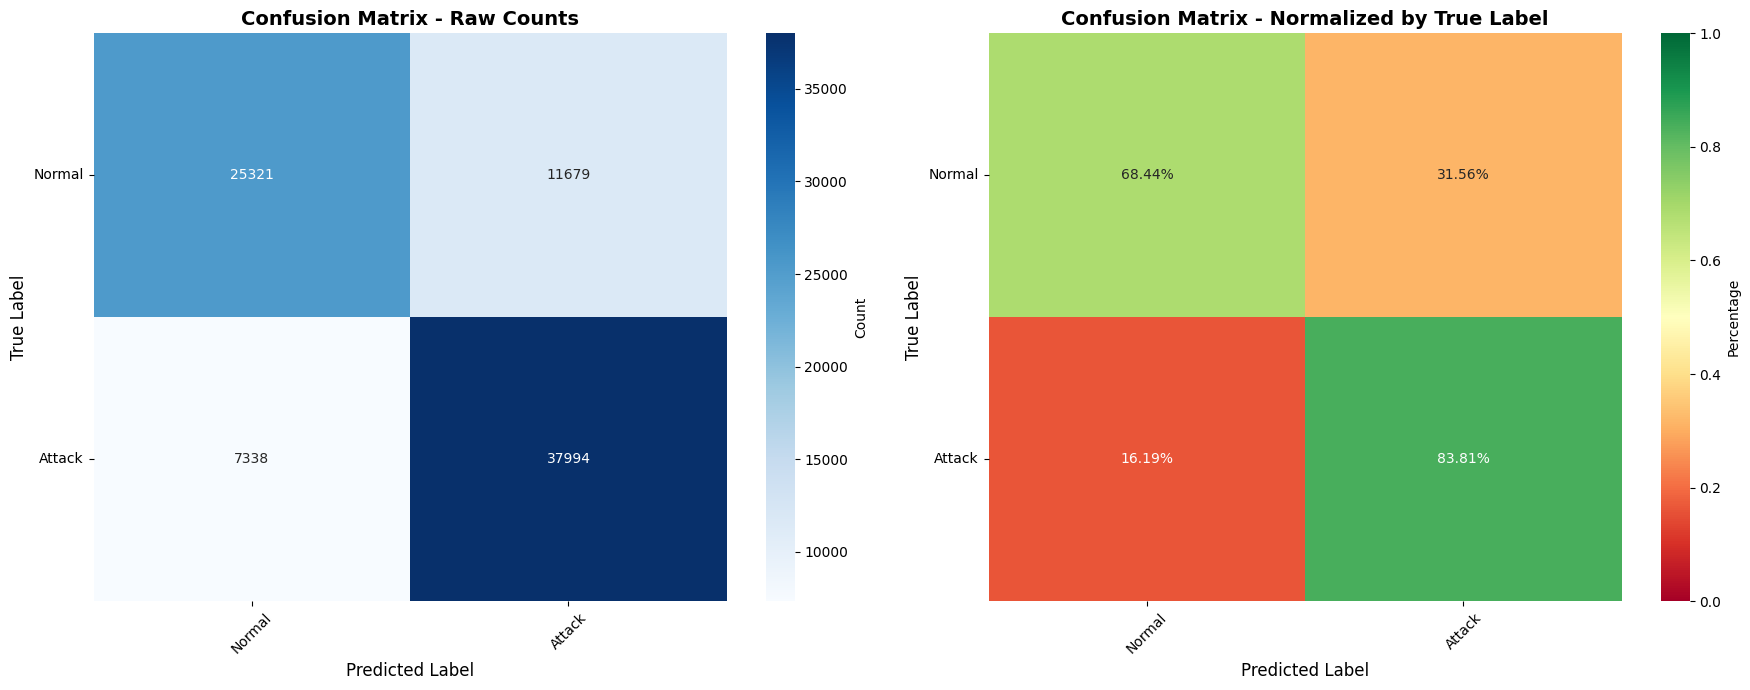

In [10]:
# Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
bin_target_names = ['Normal', 'Attack']
# Check if the target names are correct
print(f"Target names: {testing_set_processed['label'].unique()}")

bin_cm = confusion_matrix(y_test_bin, bin_preds)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Raw counts
sns.heatmap(bin_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=bin_target_names, yticklabels=bin_target_names,
            cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix - Raw Counts', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Plot 2: Normalized (percentage per true class)
bin_cm_normalized = bin_cm.astype('float') / bin_cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(bin_cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn', ax=axes[1],
            xticklabels=bin_target_names, yticklabels=bin_target_names,
            cbar_kws={'label': 'Percentage'}, vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix - Normalized by True Label', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


In [11]:
# Precision, Recall, F1-score
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

bin_target_names = ['Normal', 'Attack']

## Performance metrics
print("Accuracy:", accuracy_score(y_test_bin, bin_preds))
print("\nClassification Report:\n",
      classification_report(y_test_bin, bin_preds, target_names=bin_target_names))

Accuracy: 0.7690205509400962

Classification Report:
               precision    recall  f1-score   support

      Normal       0.78      0.68      0.73     37000
      Attack       0.76      0.84      0.80     45332

    accuracy                           0.77     82332
   macro avg       0.77      0.76      0.76     82332
weighted avg       0.77      0.77      0.77     82332



In [12]:
# False Positive Rate (FPR) and False Negative Rate (FNR)

tn, fp, fn, tp = bin_cm.ravel()
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

print(f"False Positive Rate (FPR): {fpr:.2f}")
print(f"False Negative Rate (FNR): {fnr:.2f}")

False Positive Rate (FPR): 0.32
False Negative Rate (FNR): 0.16


## 1.2 Class Attack Category Classification

In [13]:
X_train_class = training_set.drop(columns=["attack_cat", "label"])
y_train_class = training_set["attack_cat"]

X_test_class = testing_set.drop(columns=["attack_cat", "label"])
y_test_class = testing_set["attack_cat"]

attack_classes_names = y_train_class.unique()
print(attack_classes_names)

# Replace attack category names with numeric labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_class_encoded = le.fit_transform(y_train_class)
y_test_class_encoded = le.transform(y_test_class)


<StringArray>
[        'Normal',       'Backdoor',       'Analysis',        'Fuzzers',
      'Shellcode', 'Reconnaissance',       'Exploits',            'DoS',
          'Worms',        'Generic']
Length: 10, dtype: str


In [14]:
# One hot encoding for all categorical features
X_train_class = pd.get_dummies(X_train_class)
X_test_class = pd.get_dummies(X_test_class)

print(X_train_class.head())

# Aligner le set de validation sur le train
# On ajoute les colonnes manquantes (remplies de 0) et on supprime les colonnes en trop
X_test_class = X_test_class.reindex(columns=X_train_class.columns, fill_value=False)

#print(X_train_class.head())
#print(X_test_class.head())

        dur  spkts  dpkts  sbytes  dbytes       rate  sttl  dttl  \
0  0.121478      6      4     258     172  74.087490   252   254   
1  0.649902     14     38     734   42014  78.473372    62   252   
2  1.623129      8     16     364   13186  14.170161    62   252   
3  1.681642     12     12     628     770  13.677108    62   252   
4  0.449454     10      6     534     268  33.373826   254   252   

          sload          dload  ...  service_ssl  state_CON  state_ECO  \
0  14158.942380    8495.365234  ...        False      False      False   
1   8395.112305  503571.312500  ...        False      False      False   
2   1572.271851   60929.230470  ...        False      False      False   
3   2740.178955    3358.622070  ...        False      False      False   
4   8561.499023    3987.059814  ...        False      False      False   

   state_FIN  state_INT  state_PAR  state_REQ  state_RST  state_URN  state_no  
0       True      False      False      False      False      Fals

### Tuning Multi-classifier

In [15]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
import time

In [ ]:
params = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.005, 0.01, 0.05, 0.1],
    'max_depth': [1, 2, 3, 4, 5]
}


p_grid = {
        "n_estimators": randint(100, 1000),
        "colsample_bytree": uniform(0.7, 0.3),
        "gamma": uniform(0, 0.5),
        "learning_rate": uniform(0.03, 0.3),
        "max_depth": randint(2, 8),        
        "subsample": uniform(0.6, 0.4)
}

start_time = time.time()

# class_gs = GridSearchCV(XGBClassifier(n_jobs=-1, objective='multi:softprob', eval_metric='mlogloss'), params, n_jobs=-1, cv=3, scoring='f1_macro', verbose=3)
class_gs = RandomizedSearchCV(
                XGBClassifier(n_jobs=-1, 
                              objective='multi:softprob', 
                              eval_metric='mlogloss'), 
                p_grid, 
                n_jobs=-1, 
                cv=3, 
                n_iter=10,
                scoring='f1_macro', 
                verbose=3)
class_gs.fit(X_train_class, y_train_class_encoded)

end_time = time.time()

print('Best score:', class_gs.best_score_)
print('Best params:', class_gs.best_params_)
print(f"Time taken for grid search: {(end_time - start_time)/60:.1f} minutes")

Fitting 3 folds for each of 150 candidates, totalling 450 fits
Best score: 0.5754174782359286
Best params: {'colsample_bytree': np.float64(0.8274517804552703), 'gamma': np.float64(0.45783704931400965), 'learning_rate': np.float64(0.31226431095745), 'max_depth': 4, 'n_estimators': 514, 'subsample': np.float64(0.8245316723595113)}
Time taken for grid search: 186.9 minutes


### Predictions

In [17]:
# Fitting 3 folds for each of 150 candidates, totalling 450 fits
# Best score: 0.5754174782359286
# Best params: {'colsample_bytree': np.float64(0.8274517804552703), 
#               'gamma': np.float64(0.45783704931400965), 
#               'learning_rate': np.float64(0.31226431095745), 
#               'max_depth': 4, 
#               'n_estimators': 514, 
#               'subsample': np.float64(0.8245316723595113)}
# Time taken for grid search: 186.9 minutes

# Multi-class classification with XGBoost

from xgboost import XGBClassifier

# Best params from grid search
# 'colsample_bytree': 0.86 
# 'gamma': 0.41 
# 'learning_rate': 0.27 
# 'max_depth': 6, 
# 'n_estimators': 339, 
# 'subsample': 0.997


# create model instance
class_bst = XGBClassifier(# tuned
                          colsample_bytree= 0.82,
                          gamma= 0.46,
                          learning_rate= 0.31,
                          max_depth= 4,
                          n_estimators= 514,
                          subsample= 0.824,
                          # default
                          use_label_encoder= False,
                          booster= 'gbtree',
                          importance_type= 'gain', 
                          objective='multi:softprob', 
                          num_class=len(le.classes_), 
                          eval_metric='mlogloss')
# fit model
class_bst.fit(X_train_class, y_train_class_encoded)
# make predictions
class_preds = class_bst.predict(X_test_class)

c:\Users\ianis\miniconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:12:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


['Analysis' 'Backdoor' 'DoS' 'Exploits' 'Fuzzers' 'Generic' 'Normal'
 'Reconnaissance' 'Shellcode' 'Worms']


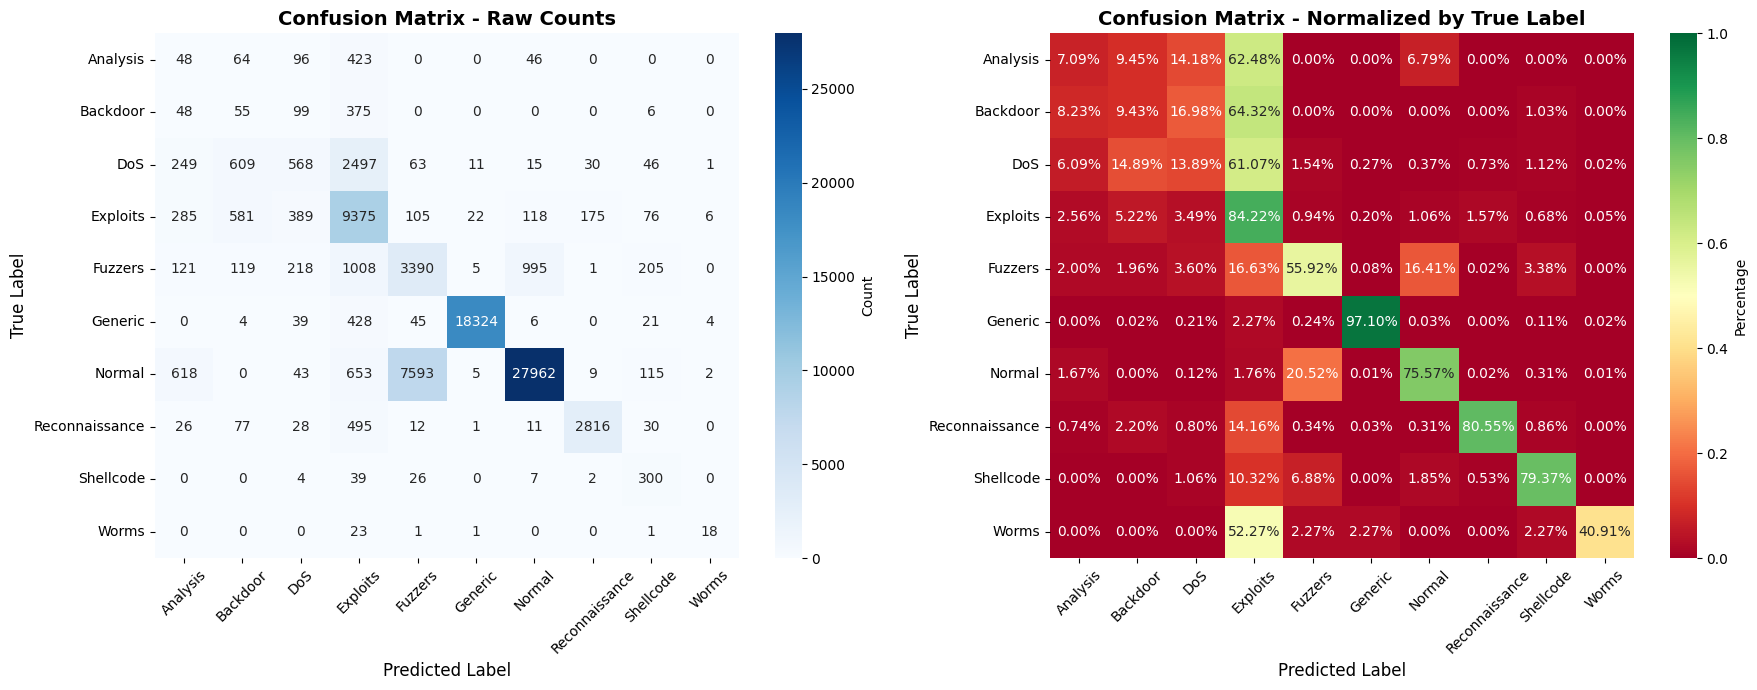

In [18]:
# Multiclass confusion matrix

# Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
class_target_names = le.classes_
print(class_target_names)

class_cm = confusion_matrix(y_test_class_encoded, class_preds)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Raw counts
sns.heatmap(class_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_target_names, yticklabels=class_target_names,
            cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix - Raw Counts', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Plot 2: Normalized (percentage per true class)
class_cm_normalized = class_cm.astype('float') / class_cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(class_cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn', ax=axes[1],
            xticklabels=class_target_names, yticklabels=class_target_names,
            cbar_kws={'label': 'Percentage'}, vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix - Normalized by True Label', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


In [19]:
# Per-class recall and F1-score

from sklearn.metrics import classification_report
class_target_names = le.classes_
print("Classification Report:\n",
      classification_report(y_test_class_encoded, class_preds, target_names=class_target_names))

Classification Report:
                 precision    recall  f1-score   support

      Analysis       0.03      0.07      0.05       677
      Backdoor       0.04      0.09      0.05       583
           DoS       0.38      0.14      0.20      4089
      Exploits       0.61      0.84      0.71     11132
       Fuzzers       0.30      0.56      0.39      6062
       Generic       1.00      0.97      0.98     18871
        Normal       0.96      0.76      0.85     37000
Reconnaissance       0.93      0.81      0.86      3496
     Shellcode       0.38      0.79      0.51       378
         Worms       0.58      0.41      0.48        44

      accuracy                           0.76     82332
     macro avg       0.52      0.54      0.51     82332
  weighted avg       0.83      0.76      0.78     82332



# 2. Context-Aware Feature Semantics 

## 2.2 Attack Behavior Profiling

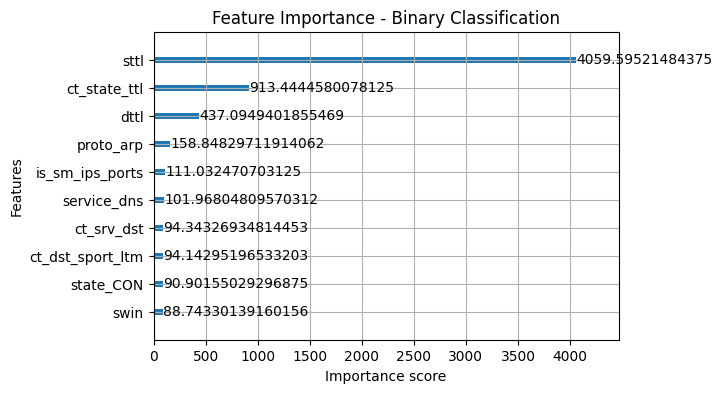

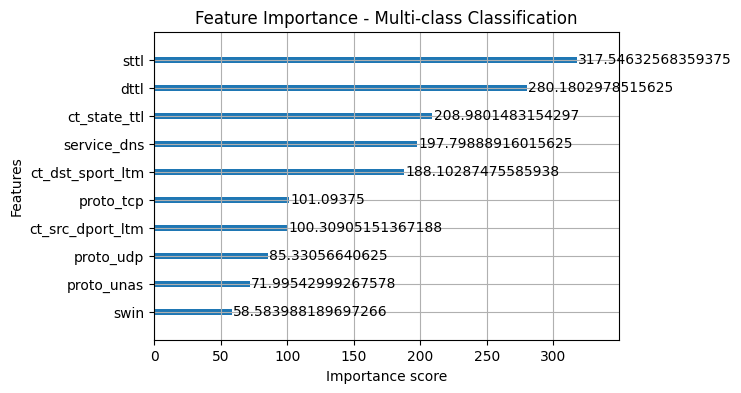

In [ ]:
from xgboost import plot_importance

plot_importance(bin_bst, importance_type='gain', max_num_features=10, title='Feature Importance - Binary Classification')
plt.rcParams['figure.figsize'] = [6, 4]
plt.show()


plot_importance(class_bst, importance_type='gain', max_num_features=10, title='Feature Importance - Multi-class Classification')
plt.rcParams['figure.figsize'] = [6, 4]
plt.show()    

In [ ]:
# plt.figure(figsize=(8, 4))
# plt.subplot(1, 3, 1)
# plt.tight_layout()
# plt.show()

# Network Context (proto, service, state) 
# o Traffic Behavior (Sload, Dload, Spkts, Dpkts) 
# o Temporal Context (dur, Stime, Ltime) 
# o Connection Patterns (ct_* features)

def stats_for_category(category_name):
    
    restricted_set = training_set.copy()
    restricted_set = restricted_set[restricted_set['attack_cat'] == category_name]

    print (f"Stats for category: {category_name}")
    print(f"Number of samples: {restricted_set.shape[0]}")

    # Load features 
    print("\n----- Load features: -----")
    for col in restricted_set.columns:
        if col not in ['attack_cat'] and restricted_set[col].dtype in ['int64', 'float64']:
            print(f"{col}: {restricted_set[col].mean():.4f} ± {restricted_set[col].std():.4f}")

    # Packet features
    print("\n----- Packet features: -----")

    # Duration
    print("\n----- Duration: -----")

    # Service usage
    print("\n----- Service usage: -----")
    
    print("-" * 50 + "\n")


# Test

stats_for_category("DoS")

stats_for_category("Exploits")

stats_for_category("Reconnaissance")


Stats for category: DoS
Number of samples: 12264

----- Load features: -----
dur: 2.5749 ± 10.4392
spkts: 22.5246 ± 230.9942
dpkts: 18.6890 ± 277.0316
sbytes: 17272.0114 ± 296395.6399
dbytes: 18969.2245 ± 367400.2184
rate: 151574.7831 ± 186871.6677
sttl: 232.8462 ± 60.8848
dttl: 48.1614 ± 98.0276
sload: 126281382.6454 ± 178605855.6631
dload: 15009.7586 ± 111400.4462
sloss: 7.1172 ± 113.2660
dloss: 7.4190 ± 137.0847
sinpkt: 87.5480 ± 415.3636
dinpkt: 18.2273 ± 60.5848
sjit: 903.9883 ± 3058.5838
djit: 111.4669 ± 805.0907
swin: 47.4278 ± 99.2245
stcpb: 399181475.2624 ± 994324538.3527
dtcpb: 400756918.3934 ± 996406460.5519
dwin: 47.4278 ± 99.2245
tcprtt: 0.0220 ± 0.0526
synack: 0.0105 ± 0.0273
ackdat: 0.0115 ± 0.0273
smean: 136.7669 ± 168.9196
dmean: 44.2266 ± 163.3585
trans_depth: 0.0940 ± 0.2971
response_body_len: 3691.6950 ± 120084.8692
ct_srv_src: 4.3619 ± 3.1056
ct_state_ttl: 1.8523 ± 0.7423
ct_dst_ltm: 2.4320 ± 2.1898
ct_src_dport_ltm: 2.0797 ± 1.4993
ct_dst_sport_ltm: 2.0538 ± 1.445

# 3. Misclassification and Security Error Analysis

## 3.1 Misclassification and Security Error Analysis

In [39]:
# Identify attack samples classified as normal

bin_false_negatives = (y_test_bin == 1) & (bin_preds == 0)
print(f"Number of attack samples classified as normal: {bin_false_negatives.sum()}")
bin_false_negatives_index = bin_false_negatives[bin_false_negatives].index

Number of attack samples classified as normal: 7338


In [ ]:
# Examples of false negatives
print("----- Examples of false negatives: -----")

index1 = bin_false_negatives_index[8]
index2 = bin_false_negatives_index[600]
index3 = bin_false_negatives_index[1534]
index4 = bin_false_negatives_index[2000]
index5 = bin_false_negatives_index[2500]
index6 = bin_false_negatives_index[3000]

# print(y_test_class.loc[bin_false_negatives_index].head(50))

# We chose these 3 indices as examples
print(f"Index of false negative examples: {index1}, {index2}, {index3}, {index4}, {index5}, {index6}\n")

print(testing_set.loc[[index1, index2, index3, index4, index5, index6]])

----- Examples of false negatives: -----
Index of false negative examples: 277, 2777, 8857

           dur proto service state  spkts  dpkts  sbytes  dbytes       rate  \
277   0.523646   tcp       -   FIN     10      6     674     268  28.645306   
2777  0.283832   tcp       -   FIN     10      6    1326     268  52.848161   
8857  0.374250   tcp    http   FIN     12     26     904   29612  98.864397   

      sttl  ...  ct_dst_sport_ltm  ct_dst_src_ltm  is_ftp_login  ct_ftp_cmd  \
277    254  ...                 1               7             0           0   
2777    62  ...                 1               1             0           0   
8857    62  ...                 1               1             0           0   

      ct_flw_http_mthd  ct_src_ltm  ct_srv_dst  is_sm_ips_ports  attack_cat  \
277                  0           1           7                0     Fuzzers   
2777                 0           3           1                0         DoS   
8857                 1           9   

## 3.2 False Positive Security Interpretation

In [36]:
# Identify normal samples classified as attack

bin_false_positives = (y_test_bin == 0) & (bin_preds == 1)
print(f"Number of normal samples classified as attack: {bin_false_positives.sum()}")
bin_false_positives_index = bin_false_positives[bin_false_positives].index

Number of normal samples classified as attack: 11679


In [ ]:
# Examples of false positives
print("----- Examples of false positives: -----")

index7 = bin_false_positives_index[8]
index8 = bin_false_positives_index[600]
index9 = bin_false_positives_index[1534]
index10 = bin_false_positives_index[2000]
index11 = bin_false_positives_index[2500]
index12 = bin_false_positives_index[3000]

# print(y_test_class.loc[bin_false_positives_index].head(50))

# We chose these 3 indices as examples
print(f"Index of false positive examples: {index7}, {index8}, {index9}, {index10}, {index11}, {index12}\n")

print(testing_set.loc[[index7, index8, index9, index10, index11, index12]])

----- Examples of false positives: -----
Index of false positive examples: 12, 41722, 43065

            dur proto service state  spkts  dpkts  sbytes  dbytes  \
12     0.000004   udp       -   INT      2      0    1454       0   
41722  2.250762   tcp       -   FIN     10      8     534     354   
43065  0.699214   tcp       -   FIN     10      6    2516     268   

                rate  sttl  ...  ct_dst_sport_ltm  ct_dst_src_ltm  \
12     250000.000600   254  ...                 1               3   
41722       7.552998   254  ...                 1               2   
43065      21.452660   254  ...                 1               2   

       is_ftp_login  ct_ftp_cmd  ct_flw_http_mthd  ct_src_ltm  ct_srv_dst  \
12                0           0                 0           1           3   
41722             0           0                 0           2           1   
43065             0           0                 0           2           2   

       is_sm_ips_ports  attack_cat  label  


# 4. Trustworthy Security Interpretation (SOC Perspective)

## 4.1 Security-Centric Evaluation (Beyond Accuracy)